In [1]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import polars as pl


### 1. Fatching the data from chemble 

In [2]:
TARGET_ID = "CHEMBL203"
target = new_client.target
activity = new_client.activity
molecule = new_client.molecule

# EFGR activities
print("Fetching efgr activities from chemble database")

results =activity.filter(
    target_chembl_id = TARGET_ID,
    assay_type="B",
    standard_type = 'IC50',
    standard_units = 'nM',
    standard_relation = '=',
    target_organism='Homo sapiens'

).only(
    "molecule_chembl_id",
    "standard_value",
    "standard_type",
    "standard_unit",
    "standard_relation",
    "pchembl_value",
    "assay_chembl_id",
    "target_chembl_id",

)

Fetching efgr activities from chemble database


In [3]:
total_records = len(results)
print(f"Total records found: {total_records}")

Total records found: 18381


In [4]:
from tqdm import tqdm

In [5]:
# collect data with progress
data = []
for records in tqdm(results, total = total_records):
    data.append(records)

# convert to dataframe
df = pl.DataFrame(data)


100%|██████████| 18381/18381 [06:02<00:00, 50.77it/s]


In [ ]:
# Save the dataset in parquet format.
df.to_parquet("../data/egfr_master_dataset.parquet")

In [11]:
df.head(20)

,assay_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_value,target_chembl_id,type,value
0,CHEMBL674637,CHEMBL68920,7.39,=,=,IC50,41.0,CHEMBL203,IC50,0.041
1,CHEMBL674637,CHEMBL69960,6.77,=,=,IC50,170.0,CHEMBL203,IC50,0.17
2,CHEMBL677833,CHEMBL137635,5.03,=,=,IC50,9300.0,CHEMBL203,IC50,9.3
3,CHEMBL674643,CHEMBL306988,None,=,=,IC50,500000.0,CHEMBL203,IC50,500.0
4,CHEMBL674643,CHEMBL66879,None,=,=,IC50,3000000.0,CHEMBL203,IC50,3000.0
5,CHEMBL674643,CHEMBL77085,4.02,=,=,IC50,96000.0,CHEMBL203,IC50,96.0
6,CHEMBL674637,CHEMBL443268,5.28,=,=,IC50,5310.0,CHEMBL203,IC50,5.31
7,CHEMBL674643,CHEMBL76979,None,=,=,IC50,264000.0,CHEMBL203,IC50,264.0
8,CHEMBL674643,CHEMBL76589,6.90,=,=,IC50,125.0,CHEMBL203,IC50,0.125
9,CHEMBL674643,CHEMBL76904,4.46,=,=,IC50,35000.0,CHEMBL203,IC50,35.0


In [28]:
# Load the data from parquet file to 
df = pd.read_parquet('../data/egfr_master_dataset.parquet')

In [29]:
df.head()

,assay_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_value,target_chembl_id,type,value
0,CHEMBL674637,CHEMBL68920,7.39,=,=,IC50,41.0,CHEMBL203,IC50,0.041
1,CHEMBL674637,CHEMBL69960,6.77,=,=,IC50,170.0,CHEMBL203,IC50,0.17
2,CHEMBL677833,CHEMBL137635,5.03,=,=,IC50,9300.0,CHEMBL203,IC50,9.3
3,CHEMBL674643,CHEMBL306988,None,=,=,IC50,500000.0,CHEMBL203,IC50,500.0
4,CHEMBL674643,CHEMBL66879,None,=,=,IC50,3000000.0,CHEMBL203,IC50,3000.0


In [30]:
# Convert to float, drop missing
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

In [31]:
df = df.dropna(subset=['standard_value'])
df = df[df['standard_value'] > 0]

In [32]:
df.shape

(18380, 10)

In [33]:
# convert IC50 to pIC50
df['pIC50'] = np.round(9 - np.log10(df['standard_value']), 2) 

In [34]:
# Final pIC50 between 2 to 12
df = df[(df['pIC50'] >= 2) & (df['pIC50'] <= 12)]

In [35]:
# flag weak compounds
df['potency_flag'] = pd.cut(df['pIC50'], 
    bins=[-np.inf, 4, 6, 9, np.inf],
    labels=['inactive_weak', 'moderate', 'potent', 'very_potent'])

In [37]:
# Deduplicate molecules (mean pIC50 per molecule)
df_dedup = df.groupby('molecule_chembl_id')['pIC50'].mean().reset_index()
df_dedup.columns = ['molecule_chembl_id', 'pIC50_mean']

In [40]:
df_dedup

,molecule_chembl_id,pIC50_mean
0,CHEMBL10,4.510
1,CHEMBL1009,4.295
2,CHEMBL101253,6.340
3,CHEMBL1016,5.480
4,CHEMBL101683,5.140
...,...,...
10515,CHEMBL97771,6.430
10516,CHEMBL98,6.985
10517,CHEMBL98248,6.770
10518,CHEMBL98798,5.120


pIC50_mean range: 2.19 – 11.52
Median: 7.03
Count: 10520


NameError: name 'plt' is not defined

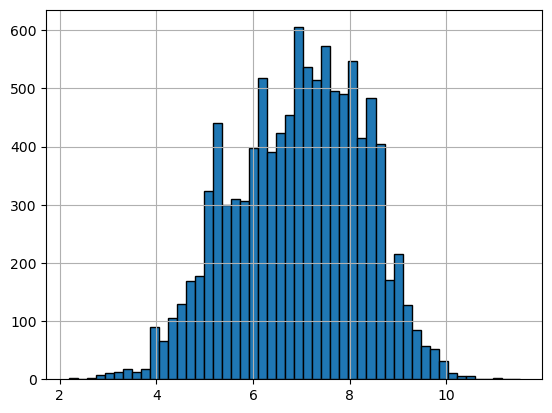

In [42]:
print(f"pIC50_mean range: {df_dedup['pIC50_mean'].min():.2f} – {df_dedup['pIC50_mean'].max():.2f}")
print(f"Median: {df_dedup['pIC50_mean'].median():.2f}")
print(f"Count: {len(df_dedup)}")

# Histogram
df_dedup['pIC50_mean'].hist(bins=50, edgecolor='black')
plt.xlabel('pIC50_mean'); plt.ylabel('Frequency'); plt.title('EGFR IC50 Potency Distribution')

In [39]:
df.shape

(18370, 12)

In [ ]:
Usage in your notebook:

  fetcher = ChEMBLFetcher("CHEMBL203")
  raw = fetcher.fetch_raw()
  curated = fetcher.curate(raw)

  # Check flagged rows
  flagged = curated[~curated["pchembl_agreement"]]
  print(f"{len(flagged)} compounds with pchembl disagreement — review these")

In [12]:
os.chdir('../')

In [13]:
os.getcwd()

'/Users/ankitkumar/Documents/Projects/egfr-pic50-prediction'

In [14]:
from src.components.data_loader import ChEMBLFetcher

In [28]:
len(df)

18381

In [29]:
len(chembl_ids)

10524

In [24]:
from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm
import pandas as pd

molecule = new_client.molecule

def chunks(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

chembl_ids = (
    df["molecule_chembl_id"]
    .dropna()
    .unique()
    .tolist()
)

batch_size = 500
all_molecules = []

batches = list(chunks(chembl_ids, batch_size))

for batch in tqdm(
    batches,
    desc="Fetching molecules",
    unit="batch"
):
    mols = molecule.filter(
        molecule_chembl_id__in=batch
    ).only(
        [
            "molecule_chembl_id",
            "molecule_structures"
        ]
    )

    all_molecules.extend(list(mols))

Fetching molecules:   0%|          | 0/22 [00:00<?, ?batch/s]

In [25]:
mol_records = []

for mol in tqdm(
    all_molecules,
    desc="Extracting SMILES",
    unit="molecule"
):
    structures = mol.get("molecule_structures")

    mol_records.append({
        "molecule_chembl_id": mol["molecule_chembl_id"],
        "canonical_smiles": (
            structures.get("canonical_smiles")
            if structures else None
        )
    })

df_mol = pd.DataFrame(mol_records)

Extracting SMILES:   0%|          | 0/10524 [00:00<?, ?molecule/s]

In [27]:
len(df_mol)

10524